# **Trabalho de Ciência de dados**
## **Classificação de Diabetes utilizando KNN e Random Forest**

## **1.Importação das Bibliotecas**

Nesta etapa são importadas as bibliotecas utilizadas ao longo do projeto para manipulação dos dados, visualização gráfica, pré-processamento, construção dos modelos de Machine Learning, avaliação dos resultados e salvamento do modelo final.

In [296]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os
import kagglehub
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import RandomOverSampler

## **2.Introdução e Conjunto de Dados**

Este trabalho tem como objetivo analisar um conjunto de dados relacionado ao diabetes e aplicar os algoritmos de classificação K-Nearest Neighbors (KNN) e Random Forest.

Inicialmente será realizada uma análise exploratória dos dados, buscando compreender suas características, identificar valores ausentes, analisar a distribuição das variáveis e investigar possíveis relações entre elas.

Posteriormente, os dados serão preparados para o treinamento dos modelos, incluindo tratamento dos valores ausentes, transformação das variáveis categóricas, padronização e balanceamento das classes.

Por fim, serão treinados e avaliados os modelos KNN e Random Forest, comparando seus desempenhos por meio de métricas de classificação.

**2.1.Obtenção do Conjunto de Dados**

Nesta etapa, o conjunto de dados de diabetes é obtido diretamente da plataforma Kaggle utilizando a biblioteca `kagglehub`. O caminho onde os arquivos foram disponibilizados é armazenado na variável `path`, permitindo o acesso ao dataset nas etapas seguintes.


In [297]:
path = kagglehub.dataset_download("imtkaggleteam/diabetes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes


**2.2.Carregamento e Visualização Inicial do Dataset**

Após a obtenção do conjunto de dados, o arquivo `diabetes.csv` é carregado em um DataFrame do Pandas. Em seguida, são exibidas as primeiras linhas do dataset para realizar uma inspeção inicial das variáveis e da estrutura dos dados.

In [298]:
krf = pd.read_csv(os.path.join(path, "diabetes.csv"))
krf.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


## **3.Análise Exploratória dos Dados**

Antes da construção dos modelos de classificação, foi realizada uma Análise Exploratória dos Dados (EDA) com o objetivo de compreender a estrutura do conjunto de dados, identificar possíveis problemas de qualidade e observar relações entre as variáveis.

Inicialmente foram analisadas as primeiras observações do dataset, a existência de registros duplicados, os tipos das variáveis e a presença de valores ausentes.

**3.1.Verificação de Registros Duplicados**

Nesta etapa é verificada a existência de registros duplicados no conjunto de dados. A presença de duplicatas pode causar distorções na análise e influenciar o treinamento dos modelos, pois algumas observações poderiam ter peso maior do que deveriam.

In [299]:
duplicates = krf.duplicated()
print(krf[duplicates])

Empty DataFrame
Columns: [id, chol, stab.glu, hdl, ratio, glyhb, location, age, gender, height, weight, frame, bp.1s, bp.1d, bp.2s, bp.2d, waist, hip, time.ppn]
Index: []


Não foram identificados registros duplicados no dataset.

**3.2.Verificação de Valores Ausentes**

Nesta etapa é verificada a quantidade de valores ausentes em cada coluna do conjunto de dados. Essa análise é importante para identificar quais variáveis precisam de tratamento antes do treinamento dos modelos.

Os valores ausentes serão tratados posteriormente de acordo com o tipo da variável, utilizando a mediana para variáveis numéricas e a moda para variáveis categóricas.

In [300]:
print(krf.isnull().sum())

id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64


A análise mostra que existem valores ausentes em algumas variáveis do conjunto de dados. A maioria das colunas apresenta uma quantidade pequena de dados faltantes, como `chol`, `hdl`, `ratio`, `height`, `weight`, `bp.1s`, `bp.1d`, `waist`, `hip` e `time.ppn`.

A variável `glyhb` apresenta 13 valores ausentes e, como será utilizada para definir a variável-alvo do problema de classificação, os registros sem esse valor serão removidos.

Também se observa uma quantidade significativamente maior de valores ausentes nas variáveis `bp.2s` e `bp.2d`, ambas com 262 registros faltantes. Os valores ausentes das variáveis utilizadas pelos modelos serão tratados posteriormente durante a etapa de pré-processamento.

**3.3.Identificação das Variáveis do Dataset**

Nesta etapa são exibidos os nomes de todas as colunas presentes no conjunto de dados. Essa verificação permite identificar quais atributos estão disponíveis para a análise exploratória e quais poderão ser utilizados posteriormente como variáveis de entrada dos modelos de classificação.

In [301]:
krf.columns

Index(['id', 'chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'location', 'age',
       'gender', 'height', 'weight', 'frame', 'bp.1s', 'bp.1d', 'bp.2s',
       'bp.2d', 'waist', 'hip', 'time.ppn'],
      dtype='object')

O conjunto de dados possui 19 variáveis. Entre elas estão informações relacionadas a colesterol (`chol`), glicose estável (`stab.glu`), HDL (`hdl`), razão entre medidas (`ratio`), hemoglobina glicada (`glyhb`), idade (`age`), gênero (`gender`), altura (`height`), peso (`weight`), estrutura corporal (`frame`), pressão arterial (`bp.1s`, `bp.1d`, `bp.2s` e `bp.2d`), medidas de cintura e quadril (`waist` e `hip`) e tempo pós-prandial (`time.ppn`).

A coluna `id` funciona como identificador dos registros, enquanto `location`, `gender` e `frame` são variáveis categóricas. As demais características são predominantemente numéricas e poderão ser analisadas e utilizadas no processo de classificação.

**3.4.Estrutura do Conjunto de Dados**

Nesta etapa é analisada a estrutura do conjunto de dados, incluindo a quantidade de registros, o número de variáveis, seus tipos e a quantidade de valores não nulos. Essa análise permite diferenciar as variáveis numéricas das categóricas e auxilia na definição das etapas de pré-processamento.

In [302]:
print(krf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB
None


O conjunto de dados apresenta variáveis numéricas dos tipos inteiro e decimal, além de variáveis categóricas representadas como texto. Essa diferença entre os tipos de dados deverá ser considerada posteriormente, pois as variáveis categóricas precisarão ser convertidas para uma representação numérica antes do treinamento dos modelos.

**3.5.Definição da Variável-Alvo**

Para transformar o problema em uma tarefa de classificação binária, foi criada a variável `index` a partir da variável `glyhb`, que representa a hemoglobina glicada (A1C).

Foi utilizado o valor de **6,5% como ponto de corte**, pois esse valor é adotado como um dos critérios laboratoriais para diabetes. Dessa forma, registros com `glyhb` maior ou igual a 6,5 foram classificados como classe 1, enquanto valores inferiores foram classificados como classe 0.

Como `glyhb` é utilizada diretamente para determinar a classe, os registros que não possuem essa informação foram removidos antes da criação da variável-alvo.

In [303]:
krf = krf.dropna(subset=['glyhb'])
krf['index'] = krf['glyhb'].apply(lambda x: 1 if x >= 6.5 else 0)
krf.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,index
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0,0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0,0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0,0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0,0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0,1


In [304]:
krf['index'].value_counts()

,count
index,
0,325
1,65


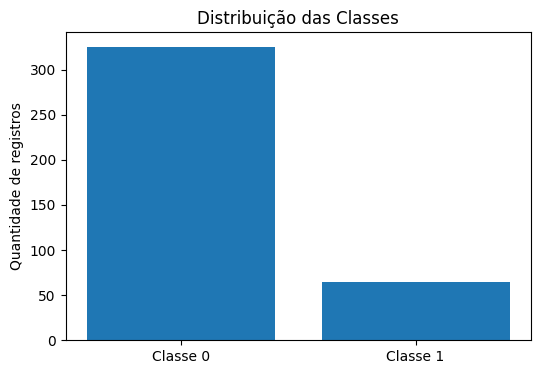

In [305]:
contagem = krf['index'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ['Classe 0', 'Classe 1'],
    contagem
)

plt.title('Distribuição das Classes')
plt.ylabel('Quantidade de registros')
plt.show()

A distribuição da variável-alvo apresenta 325 registros pertencentes à classe 0 e 65 registros pertencentes à classe 1. Portanto, aproximadamente 83,33% das observações pertencem à classe 0 e 16,67% à classe 1.

Esse resultado mostra que o conjunto de dados apresenta desbalanceamento entre as classes. Por esse motivo, posteriormente será utilizado um método de balanceamento durante o treinamento dos modelos.

**3.6.Estatísticas Descritivas**

São analisadas medidas estatísticas das variáveis numéricas, como média, desvio padrão, mínimo, máximo, mediana e quartis. Essa análise permite compreender a distribuição e principalmente as diferentes escalas existentes entre as características do conjunto de dados.

In [306]:
krf.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,390.0,16003.76,11828.81,1000.00,4792.25,15769.50,20334.25,41752.00
chol,389.0,207.28,44.71,78.00,179.00,203.00,229.00,443.00
stab.glu,390.0,107.34,53.80,48.00,81.00,90.00,107.75,385.00
hdl,389.0,50.27,17.30,12.00,38.00,46.00,59.00,120.00
ratio,389.0,4.53,1.74,1.50,3.20,4.20,5.40,19.30
glyhb,390.0,5.59,2.24,2.68,4.38,4.84,5.60,16.11
age,390.0,46.77,16.44,19.00,34.00,44.50,60.00,92.00
height,385.0,65.98,3.93,52.00,63.00,66.00,69.00,76.00
weight,389.0,177.35,40.44,99.00,150.00,173.00,200.00,325.00
bp.1s,385.0,137.15,23.00,90.00,121.00,136.00,148.00,250.00


In [307]:
print("Média de stab.glu:", np.mean(krf['stab.glu']))
print("Mediana de stab.glu:", np.median(krf['stab.glu']))

Média de stab.glu: 107.33846153846154
Mediana de stab.glu: 90.0


É possível observar que as variáveis apresentam escalas bastante diferentes, o que será especialmente importante para o KNN, já que esse algoritmo utiliza distâncias entre as observações.

**3.7.Distribuição das Variáveis Numéricas**

Foram construídos histogramas para analisar como os valores das diferentes características numéricas estão distribuídos, permitindo identificar concentração dos dados, assimetrias e possíveis valores extremos.

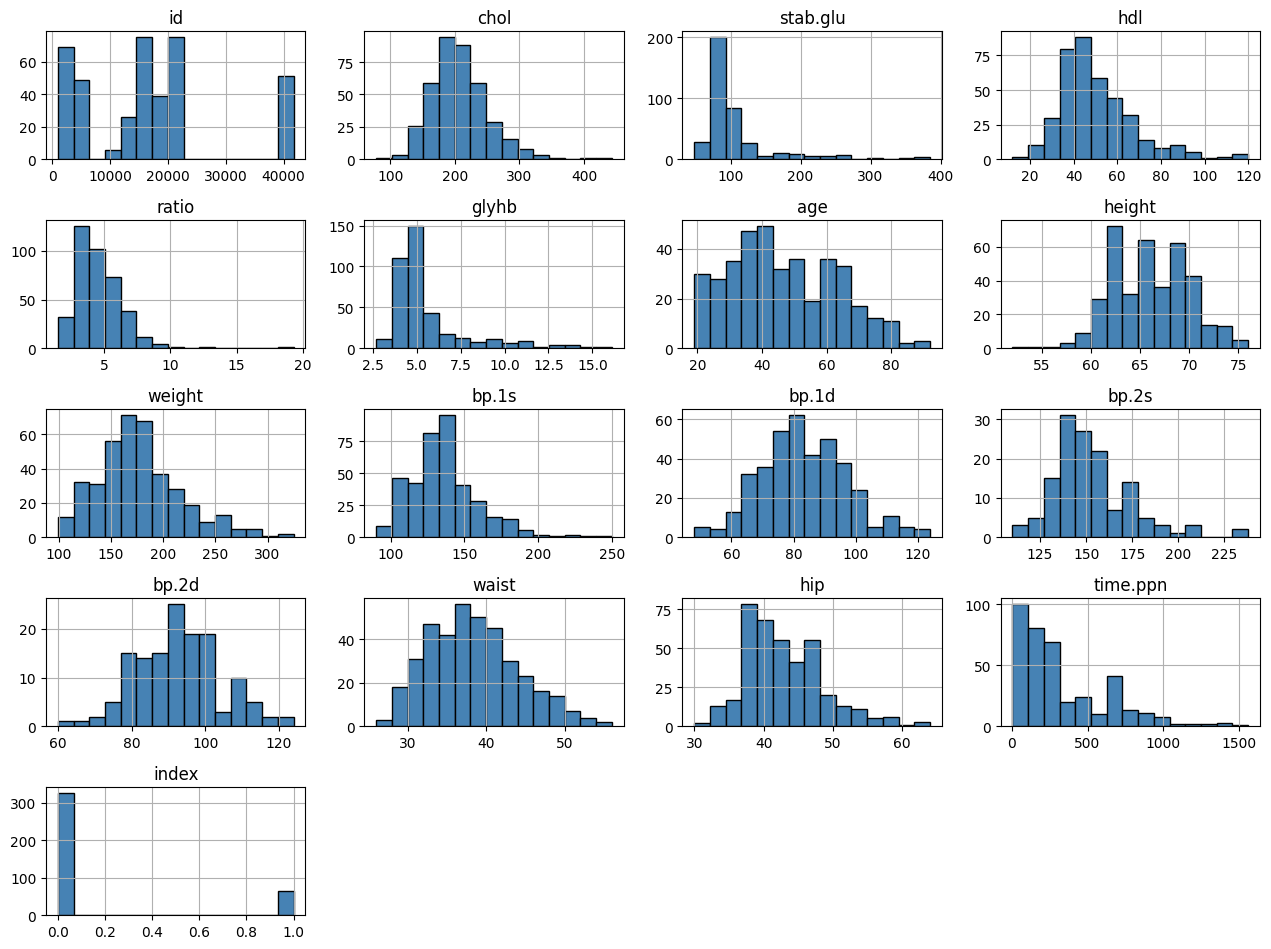

In [308]:
krf.hist(bins=15, color='steelblue', edgecolor='black',  grid=True)
plt.tight_layout(rect=(0, 0, 2, 2))

Os histogramas mostram que as características possuem distribuições e escalas distintas. Algumas variáveis apresentam maior concentração em determinados intervalos, enquanto outras possuem distribuições mais dispersas e valores extremos.

**3.8.Hipóteses**

- Hipótese 1: Pergunta: Existe algum padrão entre a idade, o nível de glicose estável (stab.glu) e a classificação dos indivíduos?
- Hipótese 2: O peso e a circunferência da cintura apresentam algum padrão associado à classificação dos indivíduos?
- Hipótese 3: A glicose estável média (stab.glu) é diferente entre indivíduos das classes 0 e 1?

**3.8.1.Hipótese 1: Relação entre Idade e Glicose Estável**

Pergunta: Existe algum padrão entre a idade, o nível de glicose estável (stab.glu) e a classificação dos indivíduos?

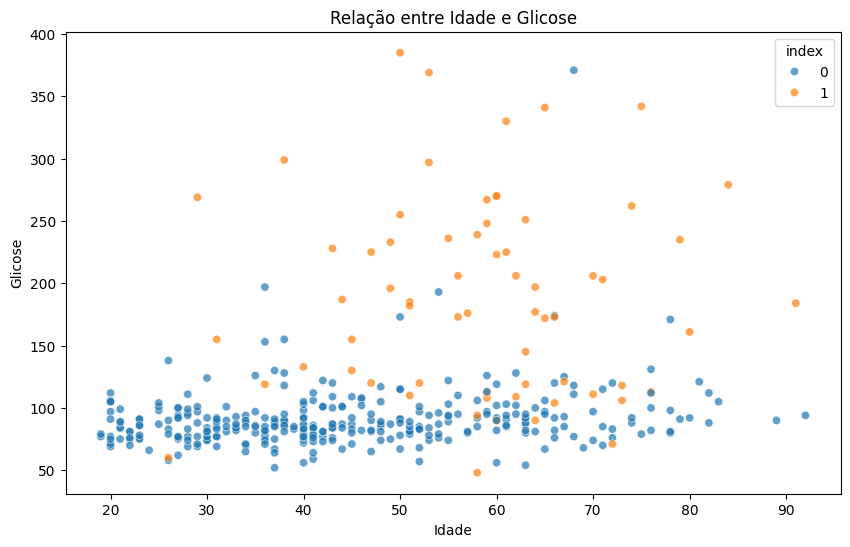

In [309]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=krf,
    x='age',
    y='stab.glu',
    hue='index',
    alpha=0.7
)

plt.title('Relação entre Idade e Glicose')
plt.xlabel('Idade')
plt.ylabel('Glicose')
plt.show()

O gráfico de dispersão mostra que os indivíduos da classe 0 estão concentrados principalmente em valores mais baixos de glicose estável, enquanto grande parte dos indivíduos da classe 1 apresenta valores mais elevados de stab.glu.

Em relação à idade, existe uma grande sobreposição entre as duas classes. Os indivíduos classificados como positivos aparecem em diversas faixas etárias, embora seja possível observar uma maior presença deles entre indivíduos de meia-idade e idosos.

A matriz de correlação também reforça essa observação. A variável stab.glu apresenta correlação de aproximadamente 0,68 com a variável-alvo index, enquanto a idade apresenta correlação de aproximadamente 0,32.

Conclusão: A glicose estável apresenta uma relação consideravelmente mais forte com a classificação do que a idade. A idade pode contribuir para a identificação das classes, mas isoladamente não é suficiente para realizar uma boa separação entre indivíduos das classes 0 e 1.

**3.8.2.Hipótese 2: Relação entre Peso e Circunferência da Cintura**

Pergunta: O peso e a circunferência da cintura apresentam algum padrão associado à classificação dos indivíduos?

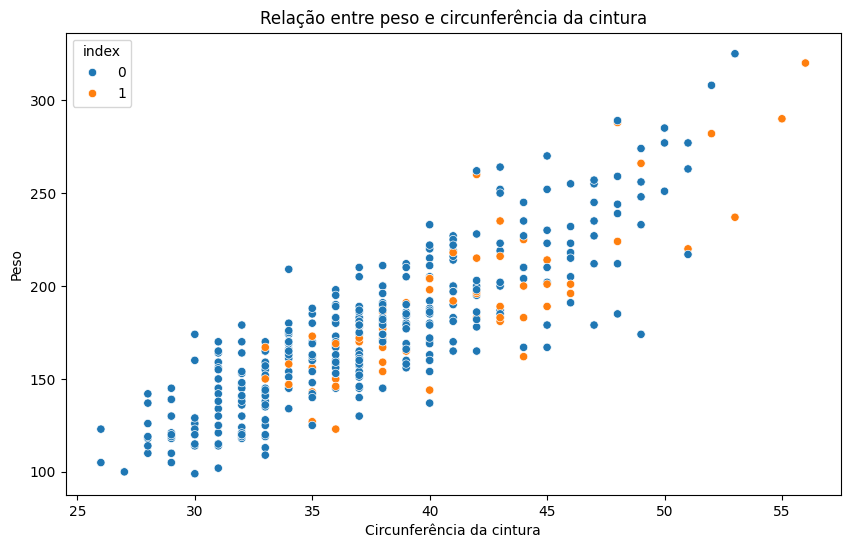

In [310]:
plt.figure(figsize=(10, 6))


sns.scatterplot(data=krf, x='waist', y='weight', hue='index')

plt.title('Relação entre peso e circunferência da cintura')
plt.xlabel('Circunferência da cintura')
plt.ylabel('Peso')
plt.show()

O gráfico de dispersão mostra uma relação positiva evidente entre a circunferência da cintura (waist) e o peso (weight). Conforme a circunferência da cintura aumenta, o peso também tende a aumentar.

Essa relação também aparece na matriz de correlação, na qual weight e waist apresentam uma correlação de aproximadamente 0,85, indicando uma forte relação entre essas duas características.

Entretanto, quando as observações são separadas pelas classes 0 e 1, ocorre uma grande sobreposição entre os grupos. Existem indivíduos das duas classes em regiões semelhantes do gráfico. Embora alguns indivíduos da classe 1 apareçam em regiões de maior peso e circunferência da cintura, não existe uma separação clara apenas utilizando essas duas características.

Conclusão: Peso e circunferência da cintura possuem forte relação entre si, porém essa combinação não é suficiente para distinguir claramente as duas classes. Essas características podem contribuir para o modelo quando utilizadas em conjunto com outras variáveis.

**3.8.3.Hipótese 3: Diferença da Glicose Estável entre as Classes**

Pergunta: A glicose estável média (stab.glu) é diferente entre indivíduos das classes 0 e 1?

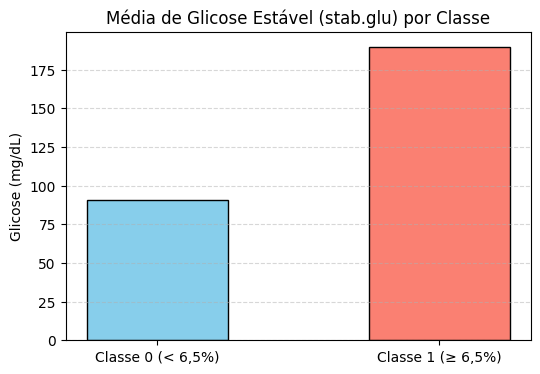

In [311]:
plt.figure(figsize=(6, 4))
plt.bar(['Classe 0 (< 6,5%)', 'Classe 1 (≥ 6,5%)'], krf.groupby('index')['stab.glu'].mean(), color=['skyblue', 'salmon'], edgecolor='black', width=0.5)
plt.title('Média de Glicose Estável (stab.glu) por Classe')
plt.ylabel('Glicose (mg/dL)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

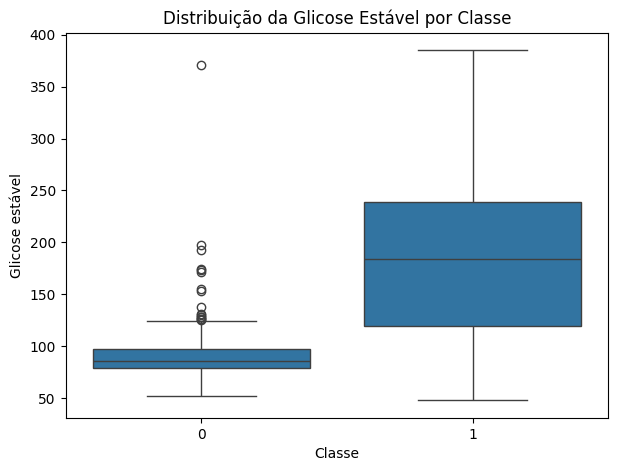

In [312]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=krf,
    x='index',
    y='stab.glu'
)

plt.title('Distribuição da Glicose Estável por Classe')
plt.xlabel('Classe')
plt.ylabel('Glicose estável')
plt.show()

Os dois gráficos mostram que a variável `stab.glu` apresenta diferenças claras entre as classes. O gráfico de barras evidencia que a média da glicose estável é maior na classe 1, enquanto o boxplot permite observar também a distribuição dos valores, a mediana, a dispersão e a presença de valores extremos em cada grupo.

A classe 1 apresenta, de forma geral, valores mais elevados de `stab.glu`, embora exista alguma sobreposição entre as distribuições.

Conclusão: os resultados sustentam a hipótese de que a glicose estável possui uma relação importante com a classificação dos indivíduos e pode contribuir significativamente para o desempenho dos modelos.

**3.9 Matriz de Correlação**

A matriz de correlação permite identificar relações lineares entre as variáveis numéricas do conjunto de dados. Valores próximos de 1 indicam correlação positiva forte, enquanto valores próximos de -1 indicam correlação negativa forte.

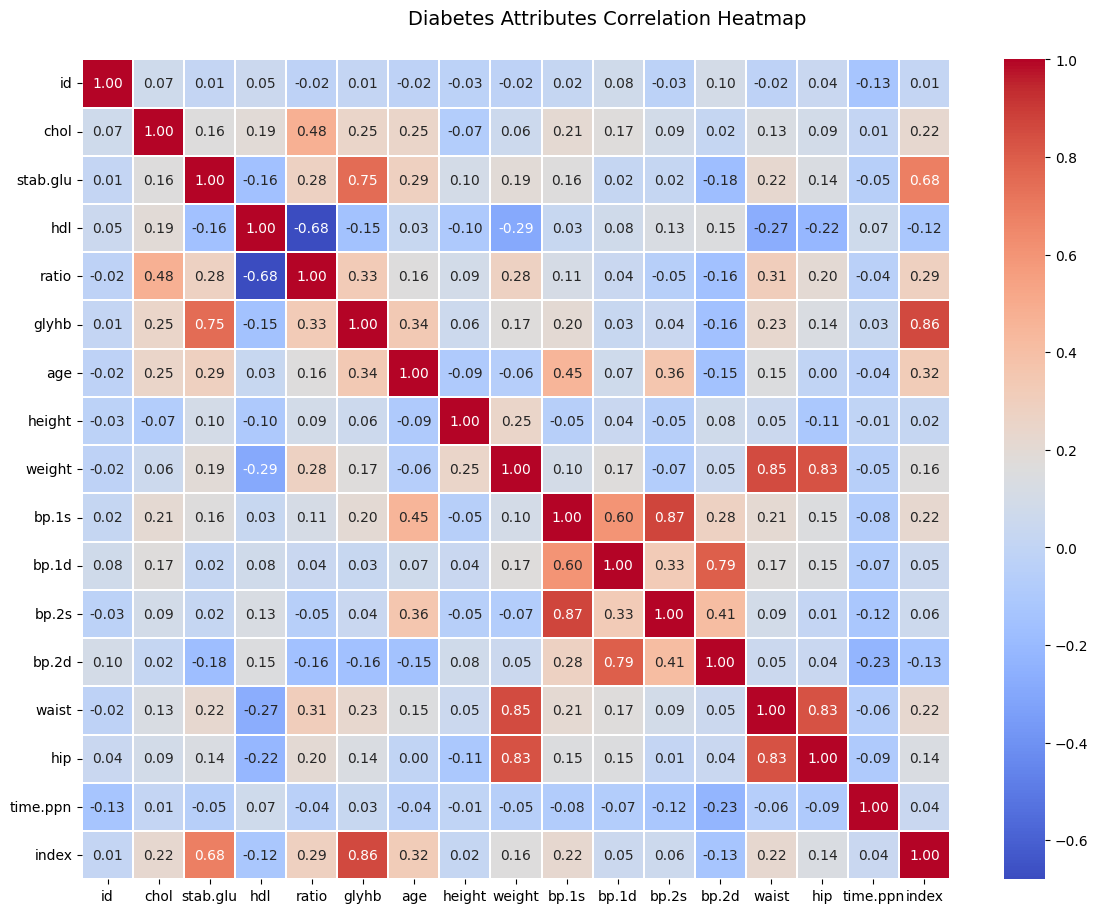

In [313]:
f, ax = plt.subplots(figsize=(14, 10))
corr = krf.corr(numeric_only=True)
hm = sns.heatmap(round(corr,2), annot=True, ax=ax, cmap="coolwarm",fmt='.2f',
                 linewidths=.05)
f.subplots_adjust(top=0.93)
t= f.suptitle('Diabetes Attributes Correlation Heatmap', fontsize=14)

Entre as maiores correlações positivas observadas estão bp.1s com bp.2s (0,87), weight com waist (0,85), weight com hip (0,83) e waist com hip (0,83). Também é possível observar uma forte correlação entre glyhb e index (0,86), mas essa relação é esperada, pois index foi criada diretamente a partir de glyhb.

Entre as correlações negativas mais fortes destaca-se hdl com ratio (-0,68). Já diversas variáveis apresentam correlações muito próximas de zero, como id com index (0,01), height com index (0,02) e time.ppn com index (0,04), indicando pouca relação linear com a variável-alvo.

## **4.Preparação e Pré-Processamento dos dados**


Após a análise exploratória, os dados precisam ser preparados para o treinamento dos modelos. Nesta etapa são definidas as variáveis de entrada e saída, realizada a divisão entre treino e teste e aplicados os tratamentos necessários para valores ausentes, variáveis categóricas, diferenças de escala e desbalanceamento das classes.

**4.1 Separação entre Variáveis de Entrada e Variável-Alvo**

Inicialmente, os dados são separados entre a variável-alvo (`y`) e as variáveis de entrada (`X`). A coluna `index` é utilizada como alvo da classificação.

As colunas `glyhb`, `index`, `location` e `id` são retiradas das variáveis de entrada. `glyhb` é removida porque foi utilizada diretamente para criar a variável-alvo, `index` representa o próprio resultado que será previsto, `id` funciona apenas como identificador e `location` não será utilizada na construção dos modelos.

In [314]:
y = krf['index']
X = krf.drop(['glyhb' ,'index', 'location', 'id'], axis=1)

**4.2 Divisão dos Dados em Treino e Teste**

O conjunto de dados é dividido em 80% para treinamento e 20% para teste. Os dados de treinamento são utilizados para construir os modelos, enquanto os dados de teste são reservados para avaliar seu desempenho.

A proporção 80/20 foi escolhida para manter a maior parte dos dados disponível para o treinamento, enquanto ainda é reservado um conjunto suficiente para avaliar o modelo. Após a remoção dos registros sem glyhb, o dataset possui 390 observações, resultando em 312 registros para treinamento e 78 para teste.

O parâmetro `stratify=y` mantém aproximadamente a mesma proporção das classes nos dois conjuntos, enquanto `random_state=42` permite reproduzir a mesma divisão em diferentes execuções.

In [315]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**4.3 Separação das Variáveis Numéricas e Categóricas**

As variáveis são separadas entre numéricas e categóricas, pois esses dois tipos de dados precisam de tratamentos diferentes. As variáveis numéricas podem ser utilizadas diretamente após o tratamento dos valores ausentes, enquanto as categóricas precisam ser transformadas em valores numéricos antes de serem utilizadas pelos modelos.

In [316]:
X_train_numeric = X_train.select_dtypes(include='number')
X_train_categoric = X_train.select_dtypes(include='object')
X_test_numeric = X_test.select_dtypes(include='number')
X_test_categoric = X_test.select_dtypes(include='object')

columns_train_numeric = X_train_numeric.columns
columns_train_categoric = X_train_categoric.columns
columns_test_numeric = X_test_numeric.columns
columns_test_categoric = X_test_categoric.columns

**4.4 Tratamento dos Valores Ausentes**

Como observado durante a análise exploratória, algumas variáveis possuem valores ausentes. Para as características numéricas, esses valores são substituídos pela mediana, que é menos influenciada por valores extremos. Para as variáveis categóricas, é utilizada a moda, substituindo os valores ausentes pela categoria mais frequente.

O tratamento é ajustado utilizando os dados de treinamento e depois aplicado aos dados de teste.

In [317]:
mediana = SimpleImputer(strategy='median')
X_train_numeric = mediana.fit_transform(X_train_numeric)
X_test_numeric = mediana.transform(X_test_numeric)

moda = SimpleImputer(strategy='most_frequent')
X_train_categoric = moda.fit_transform(X_train_categoric)
X_test_categoric = moda.transform(X_test_categoric)

**4.5 Codificação das Variáveis Categóricas**

Após o tratamento dos valores ausentes, as características categóricas são transformadas utilizando OneHotEncoder. Esse método cria representações numéricas para as diferentes categorias, permitindo que elas sejam utilizadas pelos algoritmos de classificação.

In [318]:
encoder = OneHotEncoder(
    handle_unknown= 'ignore',
    sparse_output= False
)

X_train_categoric = encoder.fit_transform(X_train_categoric)
X_test_categoric = encoder.transform(X_test_categoric)


Ao final, as variáveis numéricas e categóricas processadas são novamente reunidas para formar os conjuntos de treinamento e teste.

In [319]:
X_train_numeric = pd.DataFrame(X_train_numeric, columns=columns_train_numeric, index=X_train.index)
X_train_categoric = pd.DataFrame(X_train_categoric, columns=encoder.get_feature_names_out(), index=X_train.index)
X_test_numeric = pd.DataFrame(X_test_numeric, columns=columns_test_numeric, index=X_test.index)
X_test_categoric = pd.DataFrame(X_test_categoric, columns=encoder.get_feature_names_out(), index=X_test.index)


X_train = pd.concat([X_train_numeric, X_train_categoric], axis=1)
X_test = pd.concat([X_test_numeric, X_test_categoric], axis=1)

**4.6 Padronização dos Dados para o KNN**

Como o KNN realiza suas classificações com base na distância entre as observações, diferenças de escala entre as variáveis podem influenciar o resultado. Por esse motivo, é utilizado o StandardScaler, que coloca as características em uma escala comparável.
A padronização é ajustada com os dados de treinamento e posteriormente aplicada ao conjunto de teste.

In [320]:
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)
X_test_knn = scaler.transform(X_test)

**4.7 Balanceamento das Classes**

Durante a análise exploratória foi identificado um desbalanceamento na variável-alvo, com 325 registros da classe 0 e apenas 65 da classe 1. Esse desequilíbrio pode fazer com que os modelos favoreçam a classe majoritária.
Para reduzir esse problema, é utilizado o RandomOverSampler somente nos dados de treinamento. O método aumenta a quantidade de exemplos da classe minoritária até obter uma distribuição mais equilibrada. O procedimento é realizado separadamente para os dados utilizados pelo Random Forest e pelo KNN.

In [321]:
Smpler = RandomOverSampler(random_state=42)
X_balanced, y_balanced = Smpler.fit_resample(X_train, y_train)

In [322]:
Sampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = Sampler.fit_resample(X_train_knn, y_train)

## **5.Modelo K-Nearest Neighbors(KNN)**

**5.1 Construção do Modelo KNN**

Após o pré-processamento dos dados, o primeiro modelo utilizado foi o K-Nearest Neighbors (KNN). Esse algoritmo classifica uma nova observação considerando as classes dos exemplos mais próximos a ela.

O modelo foi treinado utilizando os dados de treinamento já padronizados e balanceados.

In [323]:
knn = KNeighborsClassifier(n_neighbors=21, weights="uniform", metric="minkowski", p=2)
knn.fit(X_resampled, y_resampled)

KNeighborsClassifier(n_neighbors=21)

**5.2 Parâmetros Utilizados**

Foram utilizados 21 vizinhos (n_neighbors=21), buscando um equilíbrio entre valores muito pequenos, que podem deixar o modelo mais sensível a ruídos, e valores muito altos, que podem generalizar demais.

O parâmetro weights="uniform" faz com que todos os 21 vizinhos tenham o mesmo peso na decisão. A métrica utilizada foi a distância de Minkowski com p=2, que corresponde à distância Euclidiana.

Como o KNN depende diretamente de distâncias, a padronização realizada anteriormente também é importante para evitar que variáveis com escalas maiores tenham influência excessiva.

**5.3 Acurácia do Modelo**

Após o treinamento, o modelo é utilizado para realizar previsões sobre o conjunto de teste. A acurácia é calculada comparando essas previsões com as classes reais.

In [324]:
knn_prediction = knn.predict(X_test_knn)
print(f"Acuracia do modelo = {accuracy_score(y_test, knn_prediction)*100}%")

Acuracia do modelo = 87.17948717948718%


O modelo KNN apresentou uma acurácia de aproximadamente 87,18%, acertando 68 das 78 observações presentes no conjunto de teste.

**5.4 Matriz de Confusão**

A matriz de confusão permite observar os acertos e erros do modelo separadamente para cada classe, oferecendo uma análise mais detalhada do que apenas a acurácia.

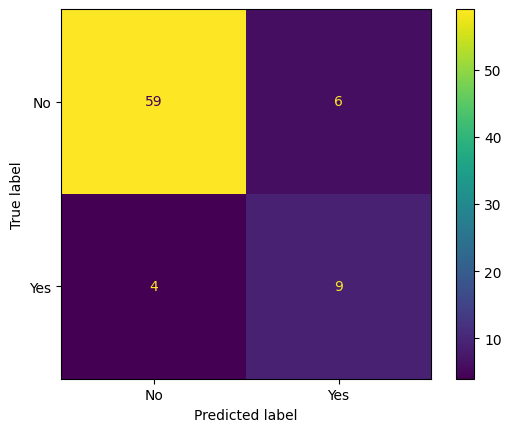

In [325]:
display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, knn_prediction), display_labels=['No', 'Yes'])
display.plot()
plt.show()

A matriz de confusão mostra que o KNN classificou corretamente 59 indivíduos da classe No e 9 da classe Yes. O modelo também apresentou 6 falsos positivos, classificando indivíduos como Yes quando pertenciam à classe No, e 4 falsos negativos, classificando como No indivíduos que pertenciam à classe Yes.

Apesar do bom desempenho geral, é possível perceber que o modelo apresenta maior dificuldade na classificação da classe Yes, que possui menos exemplos no conjunto de dados.

**5.5 Relatório de Classificação**

Além da acurácia, são analisadas as métricas de precisão, recall e F1-score, permitindo avaliar melhor o desempenho do modelo em cada uma das classes.

In [326]:
print(classification_report(y_test, knn_prediction, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.94      0.91      0.92        65
         Yes       0.60      0.69      0.64        13

    accuracy                           0.87        78
   macro avg       0.77      0.80      0.78        78
weighted avg       0.88      0.87      0.88        78



O relatório mostra um desempenho melhor para a classe No, que apresentou precisão de 0,94 e F1-score de 0,92. Para a classe Yes, a precisão foi de 0,60, o recall de 0,69 e o F1-score de 0,64.

Portanto, apesar da acurácia geral de aproximadamente 87,18%, o modelo apresenta maior facilidade para reconhecer a classe majoritária No do que a classe Yes.

## **6.Modelo Random Forest**

**6.1 Construção do Modelo Random Forest**

O segundo algoritmo utilizado foi o Random Forest, que combina várias árvores de decisão para realizar a classificação. Cada árvore contribui com uma previsão e o resultado final é definido a partir do conjunto dessas decisões.

O modelo foi treinado utilizando os dados de treinamento previamente tratados e balanceados.

In [327]:
clf = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=2, min_samples_split=6, class_weight='balanced_subsample', random_state=42)
clf.fit(X_balanced, y_balanced)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=12,
                       min_samples_leaf=2, min_samples_split=6,
                       random_state=42)

**6.2 Parâmetros Utilizados**

Foram utilizadas 100 árvores (`n_estimators=100`), permitindo combinar diferentes árvores para produzir uma classificação mais estável. O parâmetro `max_depth=12` limita a profundidade máxima das árvores, evitando que elas se tornem excessivamente complexas.

O valor `min_samples_split=6` exige pelo menos seis observações para que um nó possa ser dividido, enquanto `min_samples_leaf=2` exige pelo menos duas observações em cada folha. Esses parâmetros ajudam a reduzir o excesso de ajuste aos dados de treinamento.

O parâmetro `class_weight='balanced_subsample'` ajusta o peso das classes em cada árvore, considerando o desbalanceamento observado anteriormente. Por fim, `random_state=42` mantém os resultados reproduzíveis.

**6.3 Acurácia do Modelo**

Após o treinamento, o Random Forest realiza as previsões sobre o conjunto de teste. A acurácia é calculada comparando as classificações previstas com os valores reais.

In [328]:
clf_prediction = clf.predict(X_test)
print(f"Acuracia do modelo = {accuracy_score(y_test, clf_prediction)*100}%")

Acuracia do modelo = 94.87179487179486%


O Random Forest apresentou uma acurácia de aproximadamente 94,87%, classificando corretamente 74 das 78 observações do conjunto de teste.

O resultado indica um desempenho superior ao obtido pelo KNN.

**6.4 Matriz de Confusão**

A matriz de confusão é utilizada para analisar separadamente os acertos e erros do Random Forest em cada uma das classes.

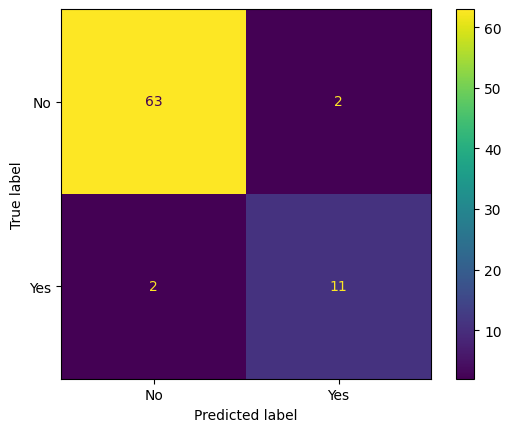

In [329]:
display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, clf_prediction), display_labels=['No', 'Yes'])
display.plot()
plt.show()

A matriz mostra que o Random Forest classificou corretamente 63 indivíduos da classe No e 11 da classe Yes. Foram registrados apenas 2 falsos positivos e 2 falsos negativos.

O resultado mostra que o modelo conseguiu manter um bom desempenho nas duas classes, inclusive na classe Yes, que possui uma quantidade menor de exemplos no conjunto original.

**6.5 Relatório de Classificação**

Além da acurácia, são avaliadas as métricas de precisão, recall e F1-score para observar o desempenho do Random Forest em cada uma das classes.

In [330]:
print(
    classification_report(
        y_test,
        clf_prediction,
        target_names=['No', 'Yes']
    )
)

              precision    recall  f1-score   support

          No       0.97      0.97      0.97        65
         Yes       0.85      0.85      0.85        13

    accuracy                           0.95        78
   macro avg       0.91      0.91      0.91        78
weighted avg       0.95      0.95      0.95        78



O relatório mostra um desempenho elevado nas duas classes. Para a classe No, o modelo apresentou aproximadamente 0,97 de precisão, recall e F1-score. Para a classe Yes, as três métricas ficaram próximas de 0,85.

Esses resultados indicam que o Random Forest conseguiu identificar melhor a classe minoritária do que o KNN, mantendo também um desempenho muito alto na classe majoritária.

**6.6 Importância das Características**

Uma das vantagens do Random Forest é permitir estimar a importância de cada característica utilizada durante a classificação. A seguir, as variáveis são ordenadas da maior para a menor importância para facilitar a interpretação do modelo.

As principais características são aproximadamente:
- `stab.glu`: 0,335
- `age`: 0,156
- `bp.1s`: 0,077
- `chol`: 0,053
- `waist`: 0,053
- `ratio`: 0,049

In [331]:
importancias = pd.Series(
    clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias)

stab.glu     0.335029
age          0.156254
bp.1s        0.077122
chol         0.053492
waist        0.053106
ratio        0.048848
hdl          0.043900
weight       0.041279
bp.1d        0.036181
time.ppn     0.032929
hip          0.032065
height       0.029759
bp.2s        0.027790
bp.2d        0.007436
x1_small     0.006628
x1_medium    0.005637
x0_female    0.004888
x1_large     0.004008
x0_male      0.003648
dtype: float64


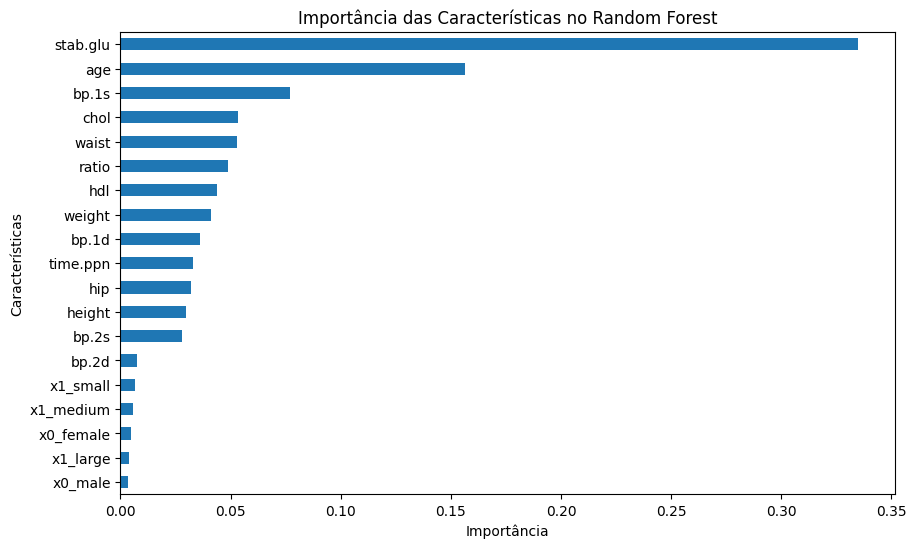

In [332]:
plt.figure(figsize=(10, 6))

importancias.sort_values().plot(kind='barh')

plt.title('Importância das Características no Random Forest')
plt.xlabel('Importância')
plt.ylabel('Características')
plt.show()

A característica com maior importância para o Random Forest foi stab.glu, representando aproximadamente 33,5% da importância calculada pelo modelo. Em seguida aparecem age, com cerca de 15,6%, e bp.1s, com aproximadamente 7,7%.

Esse resultado é coerente com a análise exploratória, na qual stab.glu já havia apresentado uma relação relevante com a variável-alvo.

## **7. Comparação dos Modelos**

Os dois modelos apresentaram resultados superiores a 85% de acurácia, porém o Random Forest obteve o melhor desempenho geral.

| Modelo | Acurácia | Precisão classe Yes | Recall classe Yes | F1-score classe Yes |
|---|---:|---:|---:|---:|
| KNN | 87,18% | 0,60 | 0,69 | 0,64 |
| Random Forest | 94,87% | 0,85 | 0,85 | 0,85 |

O KNN realiza a classificação analisando os exemplos mais próximos de cada observação. Neste trabalho foram utilizados 21 vizinhos, com pesos iguais e distância Euclidiana. A utilização de 21 vizinhos reduz a influência de casos isolados, porém o método ainda apresentou maior dificuldade para reconhecer a classe minoritária `Yes`.

O Random Forest combina o resultado de várias árvores de decisão. Foram utilizadas 100 árvores com profundidade máxima de 12, além de limites mínimos para divisão dos nós e formação das folhas. Esses parâmetros ajudam a evitar árvores excessivamente específicas. O `balanced_subsample` também considera o desbalanceamento das classes durante a construção das árvores.

Dessa forma, o Random Forest apresentou melhor capacidade de identificar padrões entre as diferentes características do conjunto de dados. Além da maior acurácia, ele apresentou valores superiores de precisão, recall e F1-score para a classe `Yes`. Por esse motivo, foi considerado o melhor modelo entre os dois avaliados.

## **8. Salvamento do Melhor Modelo**

Como o Random Forest apresentou o melhor desempenho entre os modelos avaliados, com acurácia de aproximadamente 94,87%, ele foi selecionado como modelo final.

Para permitir sua utilização posteriormente sem a necessidade de realizar um novo treinamento, o modelo foi salvo utilizando a biblioteca `joblib`.

In [333]:
joblib.dump(clf, 'modelo_rf.joblib')
print("Modelo rf salvo com sucesso como 'modelo_rf.joblib'!")

Modelo rf salvo com sucesso como 'modelo_rf.joblib'!


## **9. Conclusão**

Neste trabalho foi realizada a análise de um conjunto de dados relacionado ao diabetes, incluindo a identificação de valores ausentes, análise das características e investigação das relações entre algumas variáveis. Também foi identificado um desbalanceamento entre as classes, com maior quantidade de registros pertencentes à classe 0.

Antes do treinamento, os dados passaram por etapas de pré-processamento, incluindo tratamento dos valores ausentes, codificação das variáveis categóricas, padronização para o KNN e balanceamento das classes.

Foram avaliados os algoritmos KNN e Random Forest. O KNN apresentou acurácia de aproximadamente **87,18%**, enquanto o Random Forest alcançou aproximadamente **94,87%**. Portanto, os dois modelos ultrapassaram os 85% de acurácia estabelecidos como objetivo.

Além da maior acurácia, o Random Forest apresentou melhores resultados de precisão, recall e F1-score, principalmente na classificação da classe minoritária. Por esse motivo, ele foi selecionado como o melhor modelo e salvo para utilização posterior.